In [1]:
from fy_project.env import P2PEnergyTrading, P2PEnergyTradingAuction
from fy_project.agent import P2PTradingPolicy, P2PTradingPolicyAuction 
from fy_project.utils import print_size, to_torch

from ray.rllib.core.rl_module import RLModuleSpec, RLModule
import torch

import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
path = Path(r"C:\Users\Abhyuday Chauhan\projects\FY_project\src\config")

In [3]:
with open(path.joinpath("env_config.json")) as f:
    env_cfg = json.load(f)
agent_cfg = env_cfg['agent_cfg']

# Env w/o Auction test

In [25]:
env = P2PEnergyTrading(**env_cfg)
observation_space = env.observation_spaces['household_0']
action_space = env.action_spaces['household_0']

C:\Users\Abhyuday Chauhan\projects\FY_project\src\fy_project\IEX_data\iex_hourly_market.csv


c:\Users\Abhyuday Chauhan\.conda\envs\FY_project\Lib\site-packages\gymnasium\spaces\box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\Abhyuday Chauhan\.conda\envs\FY_project\Lib\site-packages\gymnasium\spaces\box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [65]:
obs, info = env.reset()
observation_space.contains(obs['household_0'])

2025-08-03 00:00:00


True

In [66]:
action = {"household_0" : np.random.random(size=(24,)).astype(dtype=np.float32)}

In [67]:
action_space.contains(action['household_0'])

True

In [68]:
obs, rewards, terminated, _, _ = env.step(action)

In [69]:
env.observation_spaces['household_0'].contains(obs['household_0'])

True

In [70]:
model_spec = RLModuleSpec(
        module_class=P2PTradingPolicy, 
        model_config=agent_cfg,
        observation_space=observation_space,
        action_space=action_space
    )

policy = model_spec.build()

In [76]:
test_input = {
    "market_price": torch.rand(24),
    "battery_soc": torch.rand(1),
    "battery_capacity"  : torch.rand(1),
    "forecast_demand": torch.rand(24),
    "generation": torch.rand(24)
}

In [77]:
outputs = policy.forward_inference(test_input)

In [78]:
outputs['action_dist_inputs']

tensor([-0.0649,  0.0772,  0.0350, -0.0385, -0.0676,  0.1342, -0.0199,  0.0126,
        -0.1096, -0.0649,  0.0733, -0.1074, -0.0810,  0.0387,  0.0215,  0.0688,
         0.0475, -0.0090,  0.0413,  0.0203,  0.0651, -0.1094,  0.0248,  0.0891])

In [80]:
val=policy.compute_values(test_input)
val, val.shape

(tensor([0.0900], grad_fn=<ViewBackward0>), torch.Size([1]))

In [83]:
action_space.contains(outputs['action_dist_inputs'].numpy())

True

# Env w Auction Test

In [4]:
env = P2PEnergyTradingAuction(**env_cfg)
observation_space = env.observation_spaces['household_0']
action_space = env.action_spaces['household_0']

C:\Users\Abhyuday Chauhan\projects\FY_project\src\fy_project\IEX_data\iex_daily_market.csv


c:\Users\Abhyuday Chauhan\.conda\envs\FY_project\Lib\site-packages\gymnasium\spaces\box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\Abhyuday Chauhan\.conda\envs\FY_project\Lib\site-packages\gymnasium\spaces\box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [5]:
obs, info = env.reset()
observation_space.contains(obs['household_0'])

2024-11-20 00:00:00


True

In [8]:
action = {"household_0" : np.random.random(size=(48,)).astype(dtype=np.float32)}
action_space.contains(action['household_0'])

True

In [9]:
obs, rewards, terminated, _, _ = env.step(action)

In [12]:
env.observation_spaces['household_0'].contains(obs['household_0'])

True

In [16]:
model_spec = RLModuleSpec(
        module_class=P2PTradingPolicyAuction, 
        model_config=agent_cfg,
        observation_space=observation_space,
        action_space=action_space
    )

policy = model_spec.build()

In [18]:
test_input = {
    "market_price": torch.rand(24),
    "battery_soc": torch.rand(1),
    "battery_capacity"  : torch.rand(1),
    "forecast_demand": torch.rand(24),
    "generation": torch.rand(24)
}

In [19]:
outputs = policy.forward_inference(test_input)

In [22]:
outputs['action_dist_inputs']

tensor([ 0.0144, -0.0809,  0.0333,  0.0104,  0.1188, -0.1319, -0.0324,  0.0477,
         0.0013, -0.1112,  0.0443, -0.0307,  0.1183, -0.1582,  0.0398,  0.0607,
         0.0110,  0.1648, -0.0500,  0.0717, -0.0270,  0.0602,  0.0748, -0.0846,
         0.5247,  0.4902,  0.4697,  0.4745,  0.5222,  0.5189,  0.4590,  0.5180,
         0.5094,  0.4827,  0.4840,  0.4748,  0.5349,  0.5184,  0.5067,  0.5180,
         0.4659,  0.5189,  0.5188,  0.4757,  0.4859,  0.5034,  0.4951,  0.5036,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000])

In [23]:
val=policy.compute_values(test_input)
val, val.shape

(tensor([0.0534], grad_fn=<ViewBackward0>), torch.Size([1]))

In [25]:
action_space.contains(outputs['action_dist_inputs'][:48].numpy())

True

# Env Validation

In [4]:
env = P2PEnergyTradingAuction(**env_cfg)
observation_space = env.observation_spaces['household_0']
action_space = env.action_spaces['household_0']

C:\Users\Abhyuday Chauhan\projects\FY_project\src\fy_project\IEX_data\iex_daily_market.csv


c:\Users\Abhyuday Chauhan\.conda\envs\FY_project\Lib\site-packages\gymnasium\spaces\box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\Abhyuday Chauhan\.conda\envs\FY_project\Lib\site-packages\gymnasium\spaces\box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [5]:
obs, info = env.reset()

2025-02-19 00:00:00


In [6]:
model_spec = RLModuleSpec(
        module_class=P2PTradingPolicyAuction, 
        model_config=agent_cfg,
        observation_space=observation_space,
        action_space=action_space
    )

policy = model_spec.build()

2026-03-24 22:56:16,105	WARNING rl_module.py:459 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!


In [7]:
agents = env.agents
agents

['household_0', 'household_1']

In [8]:
inputs = to_torch(obs['household_1'])
inputs

{'market_price': tensor([0.2722, 0.2757, 0.2697, 0.2673, 0.2714, 0.2914, 0.5695, 0.9091, 0.5843,
         0.4532, 0.3456, 0.3211, 0.2926, 0.2602, 0.2626, 0.2906, 0.3437, 0.3876,
         0.8047, 0.6868, 0.3601, 0.3420, 0.3081, 0.2664]),
 'battery_soc': tensor([0.5496]),
 'battery_capacity': tensor([8.2919]),
 'forecast_demand': tensor([0.1414, 0.1293, 0.1212, 0.1131, 0.1212, 0.2222, 0.3434, 0.3636, 0.2626,
         0.2020, 0.1818, 0.1697, 0.1616, 0.1697, 0.1818, 0.2222, 0.2828, 0.3636,
         0.4040, 0.3959, 0.3434, 0.2828, 0.2222, 0.1818]),
 'generation': tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1051, 0.7599, 1.5648,
         2.2913, 2.8212, 3.1724, 3.1777, 2.9134, 2.4007, 1.6931, 0.8797, 0.1669,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])}

In [9]:
action = {agent: policy.forward_inference(to_torch(inputs)) for agent in agents}
action

{'household_0': {'action_dist_inputs': tensor([-0.0737,  0.1291, -0.1145,  0.2126,  0.0461,  0.0468, -0.1782,  0.0833,
          -0.1928,  0.5838,  0.1742,  0.0386, -0.1906, -0.0115,  0.4286,  0.0824,
          -0.1000, -0.1669,  0.1362, -0.0770,  0.0448,  0.0882,  0.0181,  0.2742,
           0.5181,  0.5102,  0.4563,  0.4569,  0.5301,  0.4864,  0.5178,  0.4630,
           0.4779,  0.5438,  0.4918,  0.4934,  0.4477,  0.5115,  0.4652,  0.4536,
           0.4814,  0.4459,  0.4784,  0.5072,  0.4859,  0.4955,  0.5465,  0.4500,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.000

In [10]:
for agent in agents:
    action[agent] = action[agent]['action_dist_inputs'][:48].numpy()

In [11]:
q,p = action['household_1'][:24], action['household_1'][24:]
q, p

(array([-0.07371941,  0.12914954, -0.11450385,  0.21262704,  0.04611197,
         0.04683182, -0.17821544,  0.08331043, -0.19276537,  0.58381623,
         0.17420112,  0.03864846, -0.19056547, -0.01154765,  0.42863873,
         0.08242464, -0.10002533, -0.16689108,  0.13624525, -0.07696203,
         0.04482055,  0.08821803,  0.01809026,  0.27418298], dtype=float32),
 array([0.5181192 , 0.5101514 , 0.45628598, 0.45689073, 0.5300927 ,
        0.48640564, 0.5177746 , 0.46304762, 0.4779255 , 0.543767  ,
        0.4918403 , 0.49342012, 0.44767827, 0.5114698 , 0.46522418,
        0.45355996, 0.48138747, 0.4458729 , 0.47844857, 0.5071772 ,
        0.48585674, 0.4954817 , 0.5465093 , 0.45004654], dtype=float32))

In [12]:
action_space.contains(action['household_0'])

True

In [13]:
obs, rewards, terminated, _, info = env.step(action)

Generation : [0.         0.         0.         0.         0.         0.
 0.026792   0.193783   0.3990325  0.58427304 0.7193975  0.808962
 0.810305   0.7429255  0.61217004 0.43173203 0.224315   0.042568
 0.         0.         0.         0.         0.         0.        ]

Generation household_0: [0.         0.         0.         0.         0.         0.
 0.13396    0.968915   1.99516252 2.9213652  3.59698743 4.04480994
 4.051525   3.71462762 3.0608502  2.15866014 1.12157501 0.21284001
 0.         0.         0.         0.         0.         0.        ]

Generation household_1: [0.         0.         0.         0.         0.         0.
 0.13396    0.968915   1.99516252 2.9213652  3.59698743 4.04480994
 4.051525   3.71462762 3.0608502  2.15866014 1.12157501 0.21284001
 0.         0.         0.         0.         0.         0.        ]


In [14]:
env.agent_solar

[np.int64(5), np.int64(5)]

In [25]:
val = env._values['household_1']
val.keys()

dict_keys(['q_buy', 'agent_demand', 'Grid_exchange', 'Market_price', 'generation_forecast'])

In [26]:
hrs = np.arange(24)

In [29]:
env.agent_solar[0]

np.int64(5)

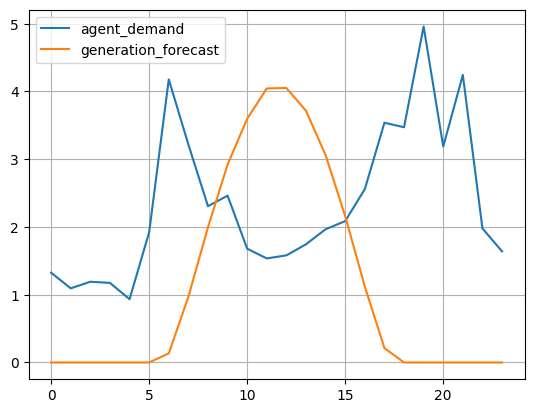

In [28]:
plt.plot(hrs, val['agent_demand'], label='agent_demand')
plt.plot(hrs, val['generation_forecast'], label='generation_forecast')
# plt.plot(hrs, val['q_buy'], label='q_buy')
plt.grid()
plt.legend()

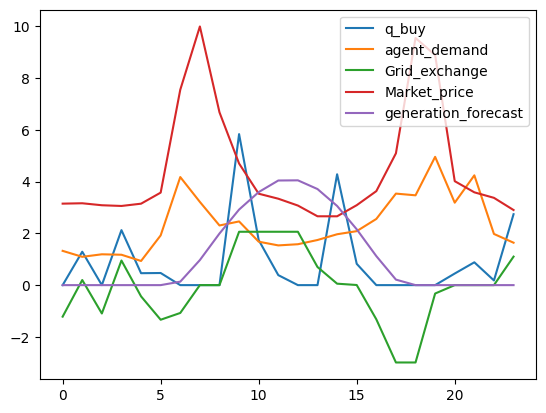

In [30]:
for key in val.keys():
    plt.plot(hrs, val[key], label=key)
plt.legend()